In [8]:
import subprocess
import os
import numpy as np
import pandas as pd

#mmseq2 databank creation to store the blasting results
fasta_file = "../lchain_sequences_deduplicated.fasta"

def mmseqs_Lchains(fasta_file, work_dir="mmseqs_Lchains"):
    os.makedirs(work_dir, exist_ok=True)
    os.makedirs(f"{work_dir}/tmp", exist_ok=True)

    # Paths
    db_path = f"{work_dir}/Lchains_db"
    res_path = f"{work_dir}/results_db"
    tmp_path = f"{work_dir}/tmp"
    out_tsv = f"{work_dir}/Lchains_mmseq2.tsv"

    #mmseqs2 database
    subprocess.run(["mmseqs", "createdb", fasta_file, db_path], check=True)

    #all-vs-all alignment
    subprocess.run([
        "mmseqs", "search", db_path, db_path, res_path, tmp_path,
        "--min-seq-id", "0.0", "-a"
    ], check=True)

    #results converted to tsv
    subprocess.run([
        "mmseqs", "convertalis", db_path, db_path, res_path, out_tsv,
        "--format-output", "query,target,fident,alnlen,bits,evalue"
    ], check=True)

    print(f"Lchains alignment saved in {out_tsv}")
    return out_tsv


#loading the file to later convert it to matrices
out_tsv = mmseqs_Lchains(fasta_file)
df = pd.read_csv(out_tsv, sep="\t", header=None,
                 names=["query", "target", "fident", "alnlen", "bitscore", "evalue"])

#
all_ids = sorted(set(df['query']).union(df['target']))

#
similarity_matrix = pd.DataFrame(0.0, index=all_ids, columns=all_ids)

#matrix filled with percentage identities
for _, row in df.iterrows():
    similarity_matrix.loc[row['query'], row['target']] = row['fident']
    similarity_matrix.loc[row['target'], row['query']] = row['fident']  

#convert to distance matrix
distance_matrix = 1 - (similarity_matrix)
np.fill_diagonal(distance_matrix.values, 0)

#save matrices
similarity_matrix.to_csv("Lchains_similarity_matrix.csv")
distance_matrix.to_csv("Lchains_distance_matrix.csv")


createdb ../lchain_sequences_deduplicated.fasta mmseqs_Lchains/Lchains_db 

MMseqs Version:       	17.b804f
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3



Input ../lchain_sequences_deduplicated.fasta does not exist


CalledProcessError: Command '['mmseqs', 'createdb', '../lchain_sequences_deduplicated.fasta', 'mmseqs_Lchains/Lchains_db']' returned non-zero exit status 1.

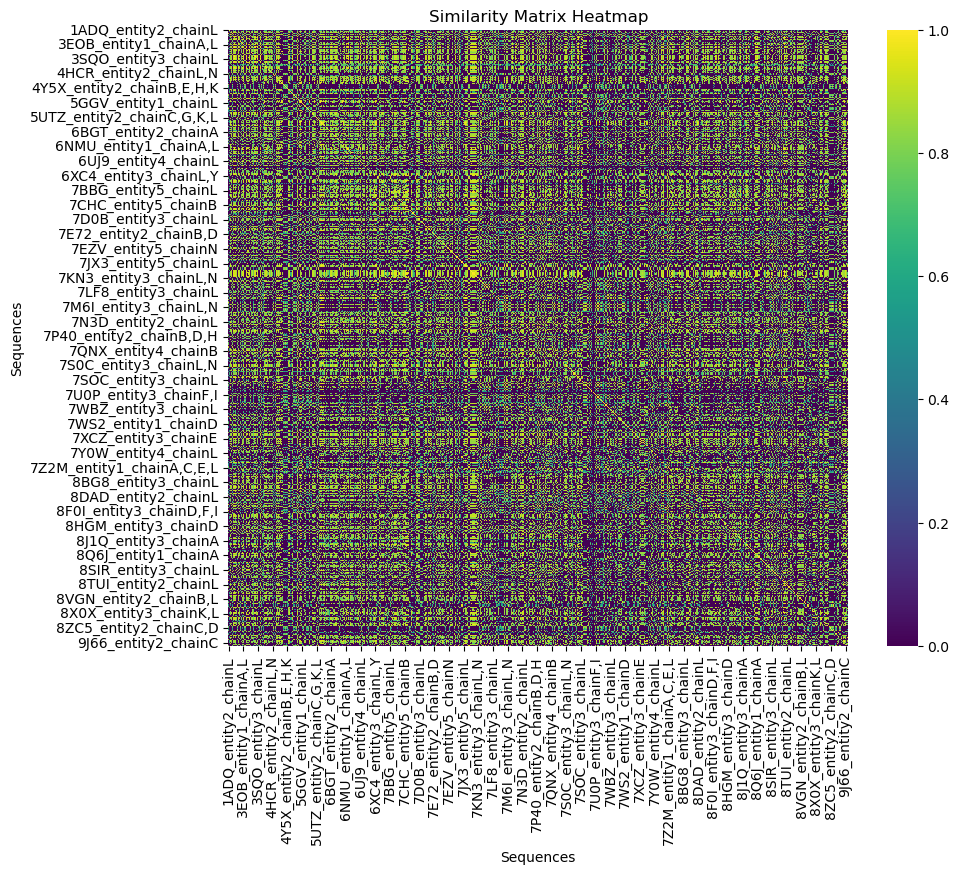

In [ ]:
#visualising the similiarity matrix 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='viridis')
plt.title("Similarity Matrix Heatmap")
plt.xlabel("Sequences")
plt.ylabel("Sequences")
plt.show()

#but is very confusing and does not provide enough information 

min = 0.0
max = 1.0
mean = 0.32226917398596133


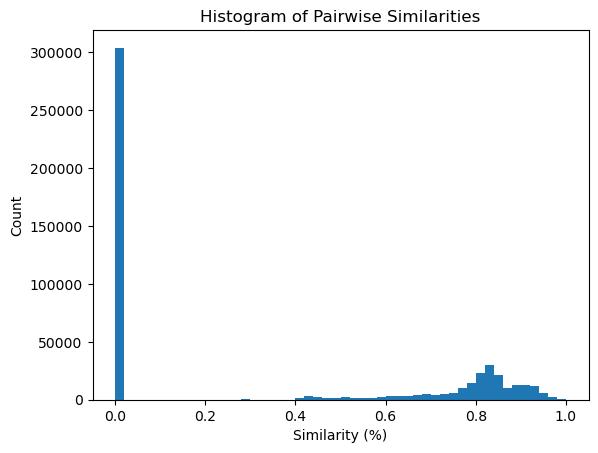

In [ ]:
#inspecting similarity matrix to ensure it is correct
import matplotlib.pyplot as plt
import numpy as np

print(f"min = {similarity_matrix.min().min()}")
print(f"max = {similarity_matrix.max().max()}")
print(f"mean = {similarity_matrix.values.mean()}")

#upper triangle values excluding diagonal
sim_values = similarity_matrix.values[np.triu_indices_from(similarity_matrix, k=1)]

plt.hist(sim_values, bins=50)
plt.title("Histogram of Pairwise Similarities")
plt.xlabel("Similarity (%)")
plt.ylabel("Count")
plt.show()


min = 0.0
max = 1.0
mean = 0.995800013097258


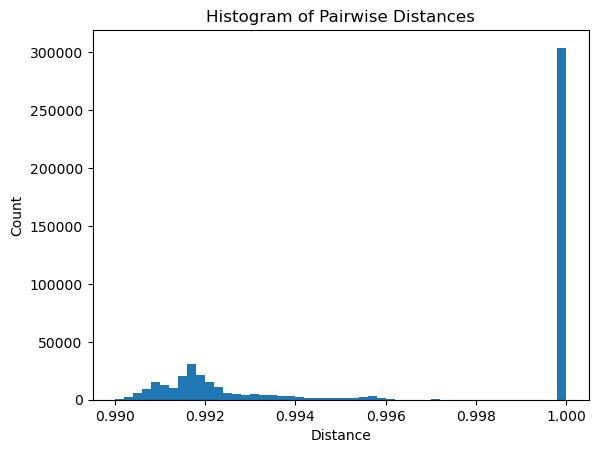

In [ ]:
#to ensure the distance matrix is correctly it should be inspected
import matplotlib.pyplot as plt
import numpy as np

#printing out the minimum, maximum, mean
print(f"min = {distance_matrix.min()}")
print(f"max = {distance_matrix.max()}")
print(f"mean = {distance_matrix.mean()}")

values = distance_matrix[np.triu_indices_from(distance_matrix, k=1)]
plt.hist(values, bins=50)
plt.title("Histogram of Pairwise Distances")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()



-> mean of around 0.995 suggests that the light chain are very dissimilar to each other 

Clusters: 2, Silhouette Score: 0.0032
Clusters: 3, Silhouette Score: 0.0033
Clusters: 4, Silhouette Score: 0.0050
Clusters: 5, Silhouette Score: 0.0044
Clusters: 6, Silhouette Score: 0.0038
Clusters: 7, Silhouette Score: 0.0023
Clusters: 8, Silhouette Score: 0.0018
Clusters: 9, Silhouette Score: 0.0016
Clusters: 10, Silhouette Score: 0.0017
Clusters: 11, Silhouette Score: 0.0016
Clusters: 12, Silhouette Score: 0.0011
Clusters: 13, Silhouette Score: 0.0009
Clusters: 14, Silhouette Score: 0.0009
Clusters: 15, Silhouette Score: 0.0007
Clusters: 16, Silhouette Score: 0.0010
Clusters: 17, Silhouette Score: 0.0009
Clusters: 18, Silhouette Score: 0.0007
Clusters: 19, Silhouette Score: 0.0006


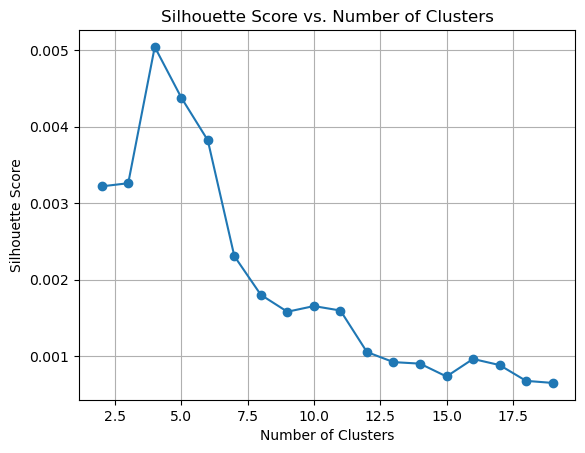

In [ ]:
#before applying PCA, the best number of clusters should be found
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#loading the distance matrix and filling the diagonal values with 0, cause mmseq2 alignment ...
distance_matrix = pd.read_csv("Lchains_distance_matrix.csv", index_col=0).values
np.fill_diagonal(distance_matrix, 0)
#different cluster counts are tried out
scores = []
for k in range(2, 20):
    clustering = AgglomerativeClustering(n_clusters=k, metric='precomputed', linkage='average')
    labels = clustering.fit_predict(distance_matrix)
    score = silhouette_score(distance_matrix, labels, metric='precomputed')
    scores.append((k, score))
    print(f"Clusters: {k}, Silhouette Score: {score:.4f}")

ks, s_scores = zip(*scores)
plt.plot(ks, s_scores, marker='o')
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

-> from the silhouette score, the closest value to 1 is achieved with 4 clusters, eventhough the values are still very small (0.005) -> is most probably going to lead to a poor clustering with PCA
-> I am going to inspect later if the problem is in the execution, or the light chains are in fact 

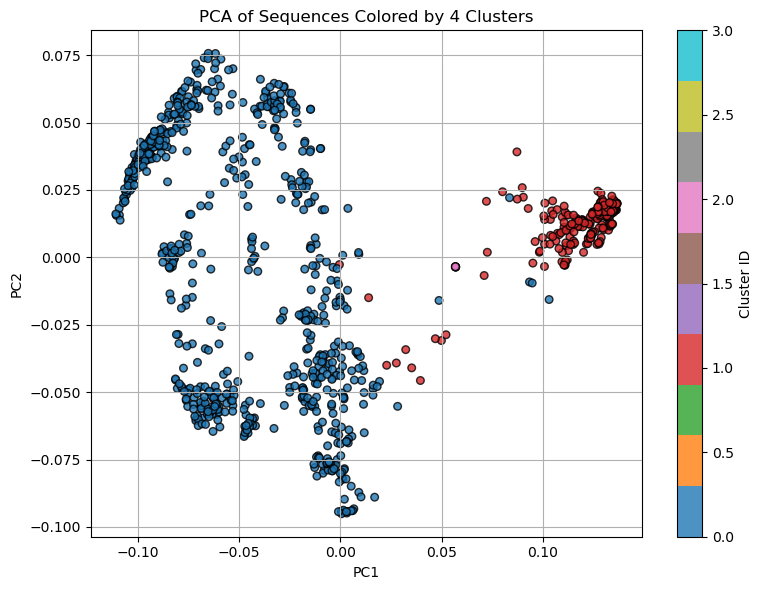

In [ ]:
#PCA dimention reduction, using dimention matrix
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

distance_matrix = pd.read_csv("Lchains_distance_matrix.csv", index_col=0)

#hierarchical clustering and choosing the number of clusters
n_clusters = 4
clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='precomputed',
    linkage='average'
)
labels = clustering.fit_predict(distance_matrix.values)

#PCA visualization
pca = PCA(n_components=2)
coords = pca.fit_transform(distance_matrix.values)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=labels, cmap='tab10',
    s=30, edgecolor='k', alpha=0.8
)

plt.title(f"PCA of Sequences Colored by {n_clusters} Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.show()

